* DI - 725
* Ayça Durmuş
* Assignment 1

In [17]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import altair as alt
import os
import numpy as np

import torch
import torch.optim as optim
import torch.nn.functional as F
from torch import nn, Tensor
device = 'cuda' if torch.cuda.is_available() else 'cpu'

* The following code is AI generated and has been also used in a previous assigment. It is meant to ensure reproducibility.

In [18]:
#the following is a llm-generated code. my aim is to make sure the results are reproducible and do not 
#change everytime i run the code 
import random

def set_seed(seed_value):
    """Set seeds for all sources of randomness."""
    
    # 1. Set seed for Python's built-in random module
    random.seed(seed_value)
    
    # 2. Set seed for NumPy (if you use it for array manipulation)
    np.random.seed(seed_value)
    
    # 3. Set seed for PyTorch (CPU and CUDA)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        # Sets the seed for the current CUDA device
        torch.cuda.manual_seed(seed_value)
        # Sets the seed for all available CUDA devices (if multi-GPU is used)
        torch.cuda.manual_seed_all(seed_value)
    
    # 4. Configure CUDNN for deterministic behavior on GPU
    # This can slightly impact performance but ensures exact reproducibility
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # 5. Set seed for the environment variable for hashing (useful for DataLoader)
    os.environ['PYTHONHASHSEED'] = str(seed_value)

SEED = 42
set_seed(SEED)

In [19]:
data_train=pd.read_csv("train.csv")
print(data_train.columns)
print(len(data_train))
data_train.head()

Index(['issue_area', 'issue_category', 'issue_sub_category',
       'issue_category_sub_category', 'customer_sentiment', 'product_category',
       'product_sub_category', 'issue_complexity', 'agent_experience_level',
       'agent_experience_level_desc', 'conversation'],
      dtype='object')
970


,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
0,Login and Account,Mobile Number and Email Verification,Verification requirement for mobile number or email address during login,Mobile Number and Email Verification -> Verification requirement for mobile number or email address during login,neutral,Appliances,Oven Toaster Grills (OTG),medium,junior,"handles customer inquiries independently, possess solid troubleshooting skills, and seek guidance from more experienced team members when needed.","Agent: Thank you for calling BrownBox Customer Support. My name is Tom. How may I assist you today?\n\nCustomer: Hi Tom, I'm trying to log in to my account to purchase an Oven Toaster Grill (OTG), but I'm unable to proceed as it's asking for mobile number or email verification. Can you help me with that?\n\nAgent: Sure, I can assist you with that. May I know your registered mobile number or email address, please?\n\nCustomer: My registered mobile number is +1 123-456-7890.\n\nAgent: Thank you. Let me check that for you. I'm sorry to inform you that we don't have this number on our records. Can you please confirm if this is the correct number?\n\nCustomer: Oh, I'm sorry. I might have registered with a different number. Can you please check with my email address instead? It's johndoe@email.com.\n\nAgent: Sure, let me check that for you. (After a few moments) I see that we have your email address on our records. We'll be sending you a verification code shortly. Please check your email and let me know once you receive it.\n\nCustomer: Okay, I received the code. What do I do with it?\n\nAgent: Please enter the verification code in the field provided and click on 'Verify'. Once your email address is verified, you'll be able to proceed with your purchase.\n\nCustomer: Okay, I entered the code, and it's verified now. Thank you for your help.\n\nAgent: You're welcome. Is there anything else I can assist you with?\n\nCustomer: No, that's all. Thank you.\n\nAgent: You're welcome. Have a great day!"
1,Cancellations and returns,Pickup and Shipping,Reasons for being asked to ship the item,Pickup and Shipping -> Reasons for being asked to ship the item,neutral,Electronics,Computer Monitor,less,junior,"handles customer inquiries independently, possess solid troubleshooting skills, and seek guidance from more experienced team members when needed.","Agent: Thank you for calling BrownBox customer support. My name is Alex. How may I assist you today?\n\nCustomer: Hi Alex. I recently received an email from BrownBox requesting me to ship back the computer monitor I purchased last week. Can you please tell me why I am being asked to ship it back?\n\nAgent: Sure, I'll be happy to help you with that. May I have your order number, please?\n\nCustomer: Yes, it's 789101.\n\nAgent: Thank you. Let me check the details of your order. (After a few seconds) I see that the monitor you purchased has been recalled by the manufacturer due to a technical issue. For safety reasons, we are requesting our customers to return the product, and we will be providing a full refund.\n\nCustomer: Oh, I see. That makes sense. Can you guide me through the process of returning the monitor?\n\nAgent: Of course. We will be sending you a prepaid shipping label via email within the next 24 hours. Please print the label, pack the monitor securely in its original packaging, and drop it off at any UPS store. Once we receive the product, we will initiate the refund process, and you will receive your money within 5-7 business days.\n\nCustomer: Okay, that sounds straightforward. Thank you for explaining the process to me.\n\nAgent: You're welcome. Is there anything else I can assist you with?\n\nCustomer: No, that's all for now. Thank you for your help.\n\nAgent: You're welcome. If you have any other questions or concerns, please don't

In [20]:
print(data_train['customer_sentiment'].value_counts())

customer_sentiment
neutral     542
negative    411
positive     17
Name: count, dtype: int64


* The training data has 970 entries and 11 columns. 
* The target variable (customer_sentiment) has 3 levels: neutral, negative, and positive. The distribution of the target variable is not balanced, which means we have to do stratified sampling while splitting this dataset to train and validation subsets.

In [21]:
print(data_train.isnull().sum())
print(data_train.shape)

issue_area                     0
issue_category                 0
issue_sub_category             0
issue_category_sub_category    0
customer_sentiment             0
product_category               0
product_sub_category           0
issue_complexity               0
agent_experience_level         0
agent_experience_level_desc    0
conversation                   0
dtype: int64
(970, 11)


* We have no null values.

In [22]:
print("Average character length of customer conversation:",data_train['conversation'].str.len().mean())
print("Average word length of customer conversation:",data_train['conversation'].str.split().str.len().mean())
word_counts=data_train['conversation'].str.split().str.len()

Average character length of customer conversation: 2129.284536082474
Average word length of customer conversation: 370.86082474226805


* It seems that the average customer interaction is short enough to feed into a transformer model (under 512-token). Let's see the distribution.

C:\Users\USER\AppData\Local\Temp\ipykernel_14748\3063794270.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


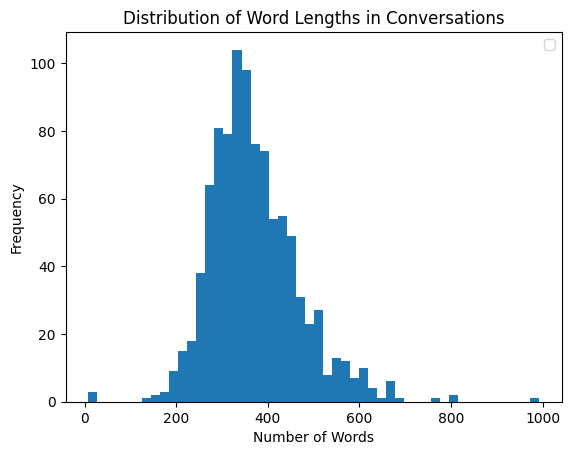

In [23]:
plt.hist(word_counts,bins=50)
plt.title('Distribution of Word Lengths in Conversations')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.show()

* The conversation length in words seem to be normally distributed. Let's do the following:
* Let's check that very short conversation to see if it is valid data point we can use.
* Let's see how many conversations exceed the 512-token length threshold we need for feeding the data into a transformer model.
* Let's see if we can remove some boiler plate text (Like "Have a nice day" or "How can I help you?") that won't tell us much about the customer sentiment analysis. The removal might let us have more conversations we can use within the token limit.
* Note: The conversation length in words do not exactly translate to token length, it is just a rough measure we will use here.

In [24]:
(data_train['conversation'].str.split().str.len()>512).sum()

np.int64(77)

In [25]:
data_train[data_train['conversation'].str.split().str.len()<50]['conversation']

191    Agent: You're welcome, Jane. Have a great day!
286    Agent: You're welcome, Jane. Have a great day!
750    Agent: You're welcome, Jane. Have a great day!
Name: conversation, dtype: object

* The following code is AI generated. The goal of this code block is to find frequently used daily phrases / sentences and removing them from the training set to optimize the training. Let's first find the common phrases / sentences.

In [26]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Initialize Vectorizer to look for sequences of 4 to 8 words
# We use a broad range to catch full sentences or common sub-phrases.
vectorizer = CountVectorizer(ngram_range=(4, 8), stop_words=None)
ngram_matrix = vectorizer.fit_transform(data_train['conversation'])

# 2. Calculate frequencies and store in a DataFrame
ngram_counts = pd.DataFrame(
    ngram_matrix.sum(axis=0).T, 
    index=vectorizer.get_feature_names_out(), 
    columns=['frequency']
).sort_values(by='frequency', ascending=False)

# Display the top 20 most frequent long phrases
print(ngram_counts.head(20))

                                      frequency
agent thank you for                        1912
agent you re welcome                       1113
is there anything else                     1026
there anything else can                     966
is there anything else can                  964
sorry to hear that                          923
customer no that all                        899
thank you for your                          897
can assist you with                         851
brownbox customer support my name is        773
support my name is                          773
customer support my name is                 773
brownbox customer support my name           773
brownbox customer support my                773
customer support my name                    773
else can assist you with                    754
anything else can assist you with           754
is there anything else can assist           754
anything else can assist you                754
else can assist you                     

* It seems that the most frequent n-grams are part of a longer sequence. Let's try to increase the n-gram to see if we can find a more coherent sentence so that removing the texts can get easier.

In [27]:
#ai
vectorizer = CountVectorizer(ngram_range=(9, 10), stop_words=None)
ngram_matrix = vectorizer.fit_transform(data_train['conversation'])

# 2. Calculate frequencies and store in a DataFrame
ngram_counts = pd.DataFrame(
    ngram_matrix.sum(axis=0).T, 
    index=vectorizer.get_feature_names_out(), 
    columns=['frequency']
).sort_values(by='frequency', ascending=False)

# Display the top 20 most frequent long phrases
print(ngram_counts.head(20))
pd.set_option('display.max_colwidth', None)

                                                               frequency
is there anything else can assist you with customer                  546
you for calling brownbox customer support my name is                 522
thank you for calling brownbox customer support my name is           522
thank you for calling brownbox customer support my name              522
there anything else can assist you with customer no                  519
is there anything else can assist you with customer no               519
anything else can assist you with customer no that                   504
there anything else can assist you with customer no that             504
anything else can assist you with customer no that all               495
else can assist you with customer no that all                        495
agent thank you for calling brownbox customer support my             418
agent thank you for calling brownbox customer support my name        418
if you have any further questions or concerns pleas

* Just to be sure, let's check if these frequent phrases have any impact on the sentiment of the customer.

In [28]:
#ai
words = vectorizer.get_feature_names_out()

# 2. Create a DataFrame of n-gram presence joined with sentiment
df_ngrams = pd.DataFrame(ngram_matrix.toarray(), columns=words)
df_ngrams['sentiment'] = data_train['customer_sentiment'].values

# 3. Calculate mean frequency per sentiment (Percentage of documents in class containing the phrase)
sentiment_impact = df_ngrams.groupby('sentiment').mean().T

# Sort by the phrases most common in 'negative' to see what drives frustration
print(sentiment_impact.sort_values(by='negative', ascending=False).head(10))

sentiment                                                   negative  \
is there anything else can assist you with customer         0.564477   
thank you for calling brownbox customer support my name is  0.547445   
you for calling brownbox customer support my name is        0.547445   
thank you for calling brownbox customer support my name     0.547445   
there anything else can assist you with customer no         0.537713   
is there anything else can assist you with customer no      0.537713   
anything else can assist you with customer no that          0.501217   
there anything else can assist you with customer no that    0.501217   
else can assist you with customer no that all               0.489051   
anything else can assist you with customer no that all      0.489051   

sentiment                                                    neutral  positive  
is there anything else can assist you with customer         0.557196  0.705882  
thank you for calling brownbox customer suppo

* As we can see, not really. The percentages are more or less distributed equally. We do see some values that are slightly higher in the positive column, however we have a very small sample size for the positive sentiment, hence even one sample can impact the score.
* We will remove these frequent phrases.

In [29]:
#ai
phrases_to_remove = [
    "thank you for calling brownbox customer support my name is",
    "is there anything else can assist you with",
    "customer no that all thank you for your help",
    "if you have any further questions or concerns please",
    "sorry to hear that",
    "thank you for",
    "sorry to hear that"
]
# Create a regex pattern: 'phrase1|phrase2|phrase3'
# The '|' acts as an 'OR' operator in regex
pattern = '|'.join(phrases_to_remove)

# Remove the phrases (case-insensitive)
data_train['conversation'] = data_train['conversation'].str.replace(pattern, '', case=False, regex=True)
# Optional: Strip extra whitespace left behind after removal
data_train['conversation'] = data_train['conversation'].str.strip().str.replace(r'\s+', ' ', regex=True) 

* Let's see the amount of above 512-word sentences left.

In [30]:
(data_train['conversation'].str.split().str.len()>512).sum()

np.int64(57)

* We managed to save some of them!
* Let's now see if the very short conversations are legit data points.

In [31]:
data_train[data_train['conversation'].str.split().str.len()<50]

,issue_area,issue_category,issue_sub_category,issue_category_sub_category,customer_sentiment,product_category,product_sub_category,issue_complexity,agent_experience_level,agent_experience_level_desc,conversation
191,Order,Order Delivery Issues,Package shows as delivered but cannot be found,Order Delivery Issues -> Package shows as delivered but cannot be found,negative,Men/Women/Kids,Shorts,less,junior,"handles customer inquiries independently, possess solid troubleshooting skills, and seek guidance from more experienced team members when needed.","Agent: You're welcome, Jane. Have a great day!"
286,Order,Order Delivery Issues,Package shows as delivered but cannot be found,Order Delivery Issues -> Package shows as delivered but cannot be found,negative,Men/Women/Kids,T-Shirt,less,inexperienced,"may struggle with ambiguous queries, rely on clarification from customers or guidance from senior team members, find it difficult to de-escalate tense situations, and may rely on predefined steps or escalate to supervisors for support","Agent: You're welcome, Jane. Have a great day!"
750,Order,Order Delivery Issues,Order approved but not shipped,Order Delivery Issues -> Order approved but not shipped,negative,Appliances,Sandwich Maker,less,experienced,"confidently handles complex customer issues, excel in de-escalation, and possess the ability to empathize with customers, providing them with effective solutions and support.","Agent: You're welcome, Jane. Have a great day!"


* They are not really conversations, so let's delete them.

* Now, let's see how the features in our data correlates with the customer sentiment.

In [ ]:
from scipy.stats import chi2_contingency
#ai
def cramers_v(x, y):
    """ Calculate Cramér's V for two categorical series. """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Correct for bias
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# List of categorical columns to check against sentiment
cols = ['issue_area', 'issue_category', 'product_category', 'issue_complexity', 'agent_experience_level','issue_sub_category']

correlations = {col: cramers_v(data_train[col], data_train['customer_sentiment']) for col in cols}
corr_df = pd.Series(correlations).sort_values(ascending=False)

print("Correlation with Customer Sentiment (Cramér's V):")
print(corr_df)

Correlation with Customer Sentiment (Cramér's V):
issue_sub_category        0.943420
issue_category            0.710983
issue_area                0.285379
agent_experience_level    0.053856
product_category          0.037802
issue_complexity          0.000000
dtype: float64


* Based on the Cramer's V feature correlation, issue sub-category, issue category, and issue area are the most relevant features for our model.
* Let's add them to the conversation column so we can train the model with just one input.